HW08-09: PyTorch MLP — регуляризация и оптимизация

In [6]:
# импортируем библиотеки 
import os 
import random
import numpy as np 
import matplotlib.pyplot as plt 

# импортируем torch 
import torch 
import torch.nn as nn
import torch.optim as optim

# датасеты для torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

%matplotlib inline

SEED = 42
DATASET_NAME = "KMNIST"
BATCH_SIZE = 256
BASE_LR = 1e-3
EPOCHS = 20
NUM_WORKERS = 0 if os.name == "nt" else 2
criterion = nn.CrossEntropyLoss()
runs = []


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print(f"Обучаем модель на {device}")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Папки артефактов созданы {FIGURES_DIR}")


device: cpu
Обучаем модель на cpu
torch: 2.10.0
torchvision: 0.25.0
Папки артефактов созданы artifacts/figures


In [ ]:

# 1. Сначала задаем трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Загружаем датасет  KMNIST 
train_full = torchvision.datasets.KMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.KMNIST(
    root='./data', train=False, download=True, transform=transform
)
class_names = train_full.classes
print("Classes:", class_names)
print("Train full size:", len(train_full))
print("Test size:", len(test_ds))

# 3.Настраиваем гиперпараметры для DataLoader

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

# 5. Создаем DataLoader
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True if str(device)=='cuda' else False
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=NUM_WORKERS, pin_memory=True if str(device)=='cuda' else False
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if str(device)=='cuda' else False
)
# Проверка 
x, y = next(iter(train_loader))
print(f"x.shape={x.shape}, y.shape={y.shape}, x.min={x.min():.4f}, x.max={x.max():.4f}")


Classes: ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']
Train full size: 60000
Test size: 10000
x.shape=torch.Size([256, 1, 28, 28]), y.shape=torch.Size([256]), x.min=-1.0000, x.max=1.0000


2.3.3. Модель MLP и цикл обучения

In [8]:
#Задание 2.3.3.1
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    x_batch, y_batch = next(iter(train_loader))
    out = model(x_batch.to(device))
print("logits:", out.shape)
#Задание 2.3.3.3
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
        
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += x.size(0)
        
    return total_loss / total, correct / total
#Задание 2.3.3.4
def training_runs(model, train_loader, val_loader, criterion, optimizer, device, max_epochs=20, early_stop_patience=None, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    
    for epoch in range(1, max_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        
        if verbose:
            print(f"Epoch {epoch:02d}/{max_epochs} | train loss={tl:.4f}, acc={ta:.4f} | val loss={vl:.4f}, acc={va:.4f}")
            
        if va > best_val_acc:
            best_val_acc = va
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            
        if early_stop_patience is not None and no_improve >= early_stop_patience:
            if verbose:
                print(f"EarlyStopping отсновка на эпохе  {epoch}")
            break
            
    if best_state is not None:
        model.load_state_dict(best_state)
        
    return history, best_val_acc, best_val_loss

logits: torch.Size([256, 10])


3.1. Часть A 

In [9]:
def plot_history(history, title="Learning Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o", markersize=4)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker="o", markersize=4)
    ax1.set_title(f"{title} - Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)
    

    ax2.plot(epochs, history["train_acc"], label="Train Acc", marker="o", markersize=4)
    ax2.plot(epochs, history["val_acc"], label="Val Acc", marker="o", markersize=4)
    ax2.set_title(f"{title} - Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()

    if title == "E4 Best Model":
        FIGURES_DIR = "artifacts/figures"
        if not os.path.exists(FIGURES_DIR): 
            os.makedirs(FIGURES_DIR)
            

        plt.savefig(os.path.join(FIGURES_DIR, "curves_best.png"), dpi=150, bbox_inches="tight")
        print("График E4 (Best Model) сохранен в artifacts/figures/curves_best.png")

    
    plt.show()

In [10]:
# E1 эсперимент часть А

set_seed(42)
model_e1 = MLP(
    hidden_dims=(256, 128), 
    dropout_p = 0.0, 
    use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=BASE_LR)
history_e1, val_acc_e1, val_loss_e1 = training_runs(
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_e1,
    device=device,
    max_epochs=EPOCHS,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "E1",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0/bn=F",
    "optimizer": "Adam",
    "lr": BASE_LR,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e1['train_loss']),
    "best_val_accuracy": val_acc_e1,
    "best_val_loss": val_loss_e1
})


Epoch 01/20 | train loss=0.6393, acc=0.8053 | val loss=0.3898, acc=0.8802
Epoch 02/20 | train loss=0.2994, acc=0.9088 | val loss=0.2722, acc=0.9183
Epoch 03/20 | train loss=0.2152, acc=0.9339 | val loss=0.2306, acc=0.9298
Epoch 04/20 | train loss=0.1640, acc=0.9506 | val loss=0.2208, acc=0.9328
Epoch 05/20 | train loss=0.1292, acc=0.9611 | val loss=0.1931, acc=0.9408
Epoch 06/20 | train loss=0.1056, acc=0.9688 | val loss=0.1766, acc=0.9452
Epoch 07/20 | train loss=0.0873, acc=0.9730 | val loss=0.1863, acc=0.9463
Epoch 08/20 | train loss=0.0728, acc=0.9776 | val loss=0.1914, acc=0.9480
Epoch 09/20 | train loss=0.0573, acc=0.9831 | val loss=0.2012, acc=0.9465
Epoch 10/20 | train loss=0.0488, acc=0.9851 | val loss=0.1855, acc=0.9515
Epoch 11/20 | train loss=0.0394, acc=0.9880 | val loss=0.1857, acc=0.9515
Epoch 12/20 | train loss=0.0324, acc=0.9901 | val loss=0.1883, acc=0.9542
Epoch 13/20 | train loss=0.0313, acc=0.9904 | val loss=0.2026, acc=0.9518
Epoch 14/20 | train loss=0.0282, acc=0

In [11]:
# E2 эсперимент часть А
set_seed(42)
model_e2 = MLP(
    hidden_dims=(256, 128), 
    dropout_p = 0.5, 
    use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=BASE_LR)
history_e2, val_acc_e2, val_loss_e2 = training_runs(
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_e2,
    device=device,
    max_epochs=EPOCHS,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "E2",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0.5/bn=F",
    "optimizer": "Adam",
    "lr": BASE_LR,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e2['train_loss']),
    "best_val_accuracy": val_acc_e2,
    "best_val_loss": val_loss_e2
})


Epoch 01/20 | train loss=0.9093, acc=0.7061 | val loss=0.4381, acc=0.8643
Epoch 02/20 | train loss=0.5162, acc=0.8441 | val loss=0.3418, acc=0.8963
Epoch 03/20 | train loss=0.4320, acc=0.8682 | val loss=0.2940, acc=0.9123
Epoch 04/20 | train loss=0.3837, acc=0.8829 | val loss=0.2701, acc=0.9202
Epoch 05/20 | train loss=0.3523, acc=0.8942 | val loss=0.2468, acc=0.9272
Epoch 06/20 | train loss=0.3287, acc=0.9028 | val loss=0.2366, acc=0.9303
Epoch 07/20 | train loss=0.3115, acc=0.9073 | val loss=0.2266, acc=0.9273
Epoch 08/20 | train loss=0.2971, acc=0.9100 | val loss=0.2151, acc=0.9308
Epoch 09/20 | train loss=0.2843, acc=0.9135 | val loss=0.2057, acc=0.9387
Epoch 10/20 | train loss=0.2755, acc=0.9159 | val loss=0.2039, acc=0.9370
Epoch 11/20 | train loss=0.2575, acc=0.9217 | val loss=0.1932, acc=0.9390
Epoch 12/20 | train loss=0.2558, acc=0.9224 | val loss=0.1916, acc=0.9433
Epoch 13/20 | train loss=0.2515, acc=0.9245 | val loss=0.1875, acc=0.9423
Epoch 14/20 | train loss=0.2438, acc=0

In [12]:
# E3 эсперимент часть А
set_seed(42)
model_e3 = MLP(
    hidden_dims=(256, 128), 
    dropout_p = 0.0, 
    use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=BASE_LR)
history_e3, val_acc_e3, val_loss_e3 = training_runs(
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_e3,
    device=device,
    max_epochs=EPOCHS,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "E3",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0/bn=T",
    "optimizer": "Adam",
    "lr": BASE_LR,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e3['train_loss']),
    "best_val_accuracy": val_acc_e3,
    "best_val_loss": val_loss_e3
})


Epoch 01/20 | train loss=0.4481, acc=0.8769 | val loss=0.2700, acc=0.9153
Epoch 02/20 | train loss=0.1639, acc=0.9525 | val loss=0.1937, acc=0.9402
Epoch 03/20 | train loss=0.1035, acc=0.9704 | val loss=0.1877, acc=0.9400
Epoch 04/20 | train loss=0.0684, acc=0.9806 | val loss=0.1707, acc=0.9490
Epoch 05/20 | train loss=0.0481, acc=0.9865 | val loss=0.1894, acc=0.9452
Epoch 06/20 | train loss=0.0357, acc=0.9904 | val loss=0.2272, acc=0.9365
Epoch 07/20 | train loss=0.0283, acc=0.9920 | val loss=0.1980, acc=0.9448
Epoch 08/20 | train loss=0.0238, acc=0.9936 | val loss=0.1978, acc=0.9477
Epoch 09/20 | train loss=0.0183, acc=0.9950 | val loss=0.2813, acc=0.9285
Epoch 10/20 | train loss=0.0149, acc=0.9964 | val loss=0.2467, acc=0.9368
Epoch 11/20 | train loss=0.0150, acc=0.9960 | val loss=0.2305, acc=0.9455
Epoch 12/20 | train loss=0.0158, acc=0.9954 | val loss=0.2139, acc=0.9478
Epoch 13/20 | train loss=0.0136, acc=0.9961 | val loss=0.1856, acc=0.9547
Epoch 14/20 | train loss=0.0110, acc=0

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 01/20 | train loss=0.4481, acc=0.8769 | val loss=0.2700, acc=0.9153
Epoch 02/20 | train loss=0.1639, acc=0.9525 | val loss=0.1937, acc=0.9402
Epoch 03/20 | train loss=0.1035, acc=0.9704 | val loss=0.1877, acc=0.9400
Epoch 04/20 | train loss=0.0684, acc=0.9806 | val loss=0.1707, acc=0.9490
Epoch 05/20 | train loss=0.0481, acc=0.9865 | val loss=0.1894, acc=0.9452
Epoch 06/20 | train loss=0.0357, acc=0.9904 | val loss=0.2272, acc=0.9365
Epoch 07/20 | train loss=0.0283, acc=0.9920 | val loss=0.1980, acc=0.9448
Epoch 08/20

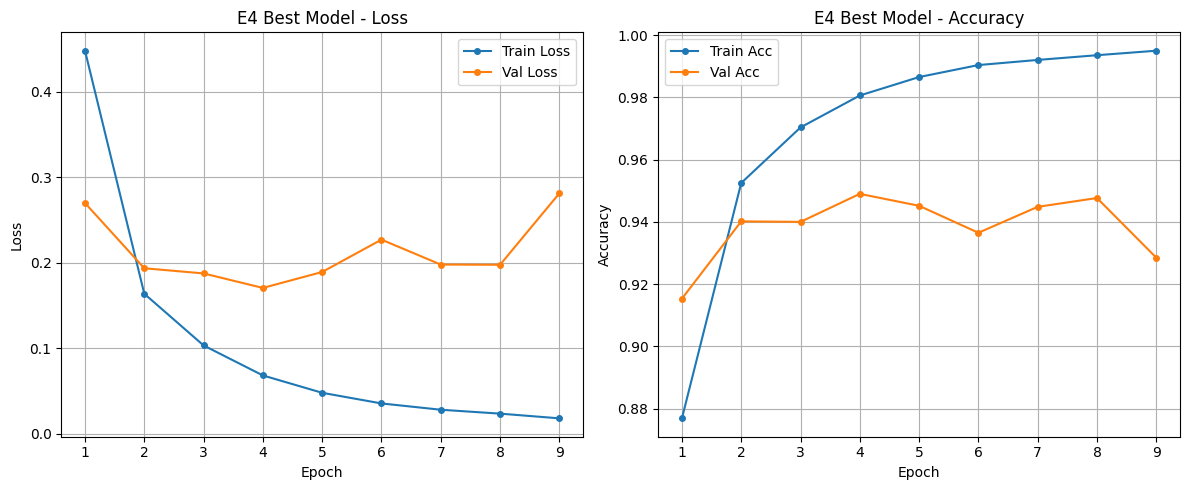

In [13]:
# E4 эсперимент часть А
set_seed(42)

use_best_of_e3_e2 = val_acc_e2 >= val_acc_e3

if use_best_of_e3_e2:

    model_e4 = MLP(hidden_dims=(256, 128), dropout_p=0.5, use_batchnorm=False).to(device)
    model_summary_e4 = "MLP + Dropout(0.5) + EarlyStopping"
    print(model_e2)
else:
    model_e4 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)
    model_summary_e4 = "MLP + BatchNorm + EarlyStopping"
    print(model_e3)

optimizer_e4 = optim.Adam(model_e4.parameters(), lr=BASE_LR)


history_e4, val_acc_e4, val_loss_e4 = training_runs(
    model=model_e4, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer_e4, 
    device=device, 
    max_epochs=EPOCHS,
    early_stop_patience=5, 
    verbose=True
)

runs.append({
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0.5/bn=F" if use_best_of_e3_e2 else "MLP/ReLU/drop=0/bn=T",
    "optimizer": "Adam",
    "lr": BASE_LR,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_e4['train_loss']),
    "best_val_accuracy": val_acc_e4,
    "best_val_loss": val_loss_e4
})

plot_history(history_e4, title="E4 Best Model")
plt.show()

###  Часть B: LR, оптимизаторы, weight decay


In [14]:
# O1 LR слишком большой: Adam, lr = 1e-1 часть B
set_seed(42)
model_o1 = MLP(
    hidden_dims=(256, 128),
    dropout_p=0.5 if use_best_of_e3_e2 else 0.0, 
    use_batchnorm=not use_best_of_e3_e2
).to(device)

optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

history_o1, val_acc_o1, val_loss_o1 = training_runs(
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_o1,
    device=device,
    max_epochs=8,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "O1",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0.5/bn=F" if use_best_of_e3_e2 else "MLP/ReLU/drop=0/bn=T",
    "optimizer": "Adam",
    "lr": 1e-1,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_o1['train_loss']),
    "best_val_accuracy": val_acc_o1,
    "best_val_loss": val_loss_o1
})


Epoch 01/8 | train loss=0.4710, acc=0.8544 | val loss=0.2980, acc=0.9070
Epoch 02/8 | train loss=0.2326, acc=0.9281 | val loss=0.2347, acc=0.9320
Epoch 03/8 | train loss=0.1782, acc=0.9456 | val loss=0.2341, acc=0.9317
Epoch 04/8 | train loss=0.1590, acc=0.9521 | val loss=0.2380, acc=0.9288
Epoch 05/8 | train loss=0.1285, acc=0.9591 | val loss=0.2308, acc=0.9343
Epoch 06/8 | train loss=0.1190, acc=0.9626 | val loss=0.2222, acc=0.9395
Epoch 07/8 | train loss=0.1012, acc=0.9678 | val loss=0.2563, acc=0.9353
Epoch 08/8 | train loss=0.0941, acc=0.9711 | val loss=0.2576, acc=0.9360


In [15]:
# O2 LR слишком маленький: Adam, lr = 1e-5 часть B
set_seed(42)
model_o2 = MLP(
    hidden_dims=(256, 128),
    dropout_p=0.5 if use_best_of_e3_e2 else 0.0,
    use_batchnorm=not use_best_of_e3_e2
).to(device)

optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2, val_acc_o2, val_loss_o2 = training_runs(
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_o2,
    device=device,
    max_epochs=8,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "O2",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0.5/bn=F" if use_best_of_e3_e2 else "MLP/ReLU/drop=0/bn=T",
    "optimizer": "Adam",
    "lr": 1e-5,
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": len(history_o2['train_loss']),
    "best_val_accuracy": val_acc_o2,
    "best_val_loss": val_loss_o2
})


Epoch 01/8 | train loss=2.0082, acc=0.2985 | val loss=1.7075, acc=0.4742
Epoch 02/8 | train loss=1.5268, acc=0.5887 | val loss=1.3671, acc=0.6745
Epoch 03/8 | train loss=1.2713, acc=0.7086 | val loss=1.1833, acc=0.7370
Epoch 04/8 | train loss=1.1122, acc=0.7559 | val loss=1.0481, acc=0.7705
Epoch 05/8 | train loss=0.9987, acc=0.7865 | val loss=0.9528, acc=0.7913
Epoch 06/8 | train loss=0.9111, acc=0.8085 | val loss=0.8770, acc=0.8082
Epoch 07/8 | train loss=0.8394, acc=0.8251 | val loss=0.8149, acc=0.8200
Epoch 08/8 | train loss=0.7788, acc=0.8371 | val loss=0.7622, acc=0.8322


In [16]:
# O3 SGD + momentum + weight_decay: SGD, momentum=0.9, wd=1e-4, lr=1e-2 часть B
set_seed(42)
model_o3 = MLP(
    hidden_dims=(256, 128),
    dropout_p=0.5 if use_best_of_e3_e2 else 0.0,
    use_batchnorm=not use_best_of_e3_e2
).to(device)

optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

history_o3, val_acc_o3, val_loss_o3 = training_runs(
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_o3,
    device=device,
    max_epochs=15,
    early_stop_patience=None,
    verbose=True
)

runs.append({
    "experiment_id": "O3",
    "dataset": DATASET_NAME,
    "seed": 42,
    "model_summary": "MLP/ReLU/drop=0.5/bn=F" if use_best_of_e3_e2 else "MLP/ReLU/drop=0/bn=T",
    "optimizer": "SGD",
    "lr": 1e-2,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "epochs_trained": len(history_o3['train_loss']),
    "best_val_accuracy": val_acc_o3,
    "best_val_loss": val_loss_o3
})


Epoch 01/15 | train loss=0.5843, acc=0.8317 | val loss=0.3052, acc=0.9125
Epoch 02/15 | train loss=0.2204, acc=0.9383 | val loss=0.2174, acc=0.9365
Epoch 03/15 | train loss=0.1444, acc=0.9602 | val loss=0.1844, acc=0.9443
Epoch 04/15 | train loss=0.1028, acc=0.9726 | val loss=0.1977, acc=0.9358
Epoch 05/15 | train loss=0.0745, acc=0.9814 | val loss=0.1649, acc=0.9507
Epoch 06/15 | train loss=0.0543, acc=0.9875 | val loss=0.1633, acc=0.9503
Epoch 07/15 | train loss=0.0405, acc=0.9914 | val loss=0.1738, acc=0.9480
Epoch 08/15 | train loss=0.0306, acc=0.9942 | val loss=0.1581, acc=0.9543
Epoch 09/15 | train loss=0.0226, acc=0.9965 | val loss=0.1595, acc=0.9555
Epoch 10/15 | train loss=0.0183, acc=0.9975 | val loss=0.1607, acc=0.9520
Epoch 11/15 | train loss=0.0141, acc=0.9985 | val loss=0.1579, acc=0.9542
Epoch 12/15 | train loss=0.0115, acc=0.9990 | val loss=0.1645, acc=0.9538
Epoch 13/15 | train loss=0.0090, acc=0.9994 | val loss=0.1568, acc=0.9557
Epoch 14/15 | train loss=0.0075, acc=0

Графики O1/O2 сохранены в artifacts/figures/curves_lr_extremes.png


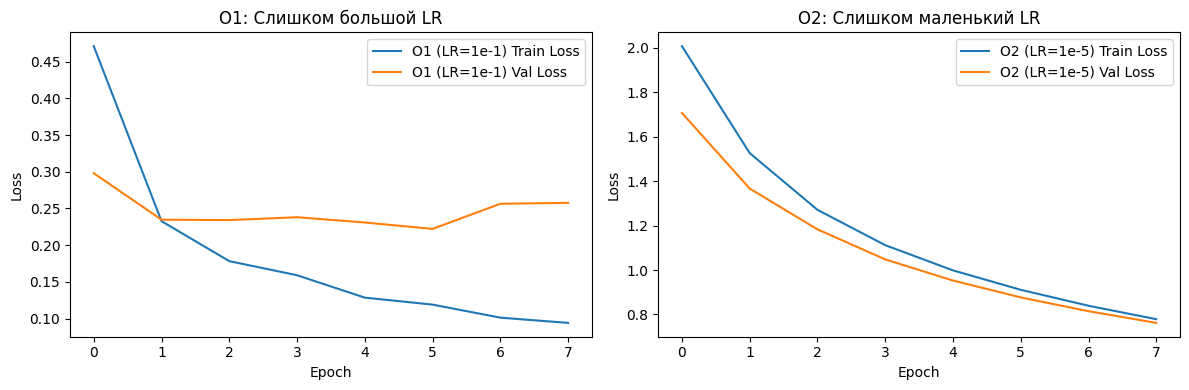

In [17]:
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_o1['train_loss'], label='O1 (LR=1e-1) Train Loss')
axes[0].plot(history_o1['val_loss'], label='O1 (LR=1e-1) Val Loss')
axes[0].set_title('O1: Слишком большой LR')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_o2['train_loss'], label='O2 (LR=1e-5) Train Loss')
axes[1].plot(history_o2['val_loss'], label='O2 (LR=1e-5) Val Loss')
axes[1].set_title('O2: Слишком маленький LR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()



FIGURES_DIR = "artifacts/figures"
if not os.path.exists(FIGURES_DIR): os.makedirs(FIGURES_DIR)
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"))
print("Графики O1/O2 сохранены в artifacts/figures/curves_lr_extremes.png")
plt.show()


### 4. Экспорт результатов в runs.csv

In [18]:
import pandas as pd

df_runs = pd.DataFrame(runs)
df_runs.to_csv("artifacts/runs.csv", index=False)
print("Результаты всех экспериментов сохранены в artifacts/runs.csv")
df_runs.head(10)

Результаты всех экспериментов сохранены в artifacts/runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,KMNIST,42,MLP/ReLU/drop=0/bn=F,Adam,0.00100,0.0,0.0000,20,0.954333,0.216657
1,E2,KMNIST,42,MLP/ReLU/drop=0.5/bn=F,Adam,0.00100,0.0,0.0000,20,0.946833,0.174606
2,E3,KMNIST,42,MLP/ReLU/drop=0/bn=T,Adam,0.00100,0.0,0.0000,20,0.954667,0.185567
3,E4,KMNIST,42,MLP/ReLU/drop=0/bn=T,Adam,0.00100,0.0,0.0000,9,0.949000,0.170711
4,O1,KMNIST,42,MLP/ReLU/drop=0/bn=T,Adam,0.10000,0.0,0.0000,8,0.939500,0.222157
5,O2,KMNIST,42,MLP/ReLU/drop=0/bn=T,Adam,0.00001,0.0,0.0000,8,0.832167,0.762207
6,O3,KMNIST,42,MLP/ReLU/drop=0/bn=T,SGD,0.01000,0.9,0.0001,15,0.956000,0.158855



Test Loss: 0.3845 | Test Acc: 0.8911
Лучшая модель сохранена в artifacts/best_model.pt
Конфигурация лучшей модели сохранена в artifacts/best_config.json


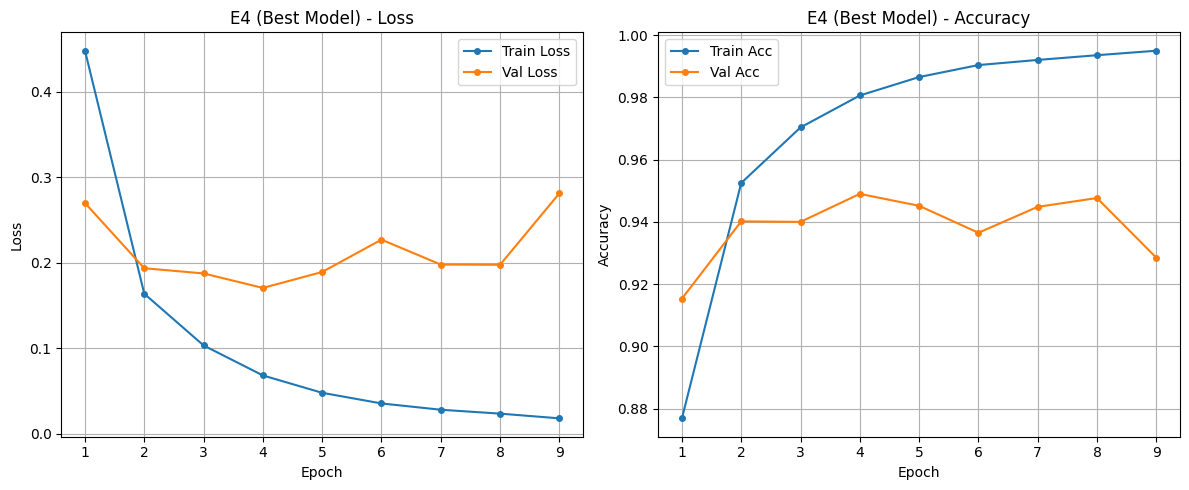

In [19]:
# тест лучшей модели E4

test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
print("Лучшая модель сохранена в artifacts/best_model.pt")

import json

best_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_type": model_summary_e4,
    "hidden_sizes": [256, 128],     
    "dropout_p": 0.5 if use_best_of_e3_e2 else 0.0,
    "use_batchnorm": not use_best_of_e3_e2,
    "optimizer": "Adam", 
    "lr": BASE_LR, 
    "early_stopping_patience": 5, 
    "epochs_trained": len(history_e4['train_loss']),    
    "best_val_accuracy": val_acc_e4,
    "best_val_loss": val_loss_e4,            
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f)
print("Конфигурация лучшей модели сохранена в artifacts/best_config.json")

plot_history(history_e4, title="E4 (Best Model)")
